<a href="https://colab.research.google.com/github/J05ia5/ML-lab/blob/main/lab7_quickdraw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Clustering

# ML - Aprendizaje No Supervisado

En la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (*Unsupervised Learning*), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

El *Clustering* es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados *clusters*. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 10
Coordenadas de los centroides:
[[-5.09383242  5.32041851]
 [ 1.11247837  6.69825321]
 [-1.10372565  0.73344393]
 [-1.84985863 -7.14408201]
 [-6.22897839  3.04052189]
 [-3.33033975 -3.06104444]
 [-4.13671291  8.25657177]
 [ 8.87942256 -3.82195851]
 [-6.32030682 -3.29812944]
 [ 6.6974042  -1.16120415]]


In [33]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

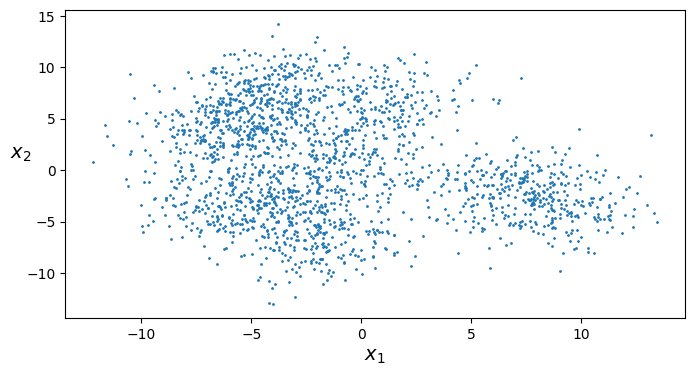

In [34]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [35]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([2, 7, 0, ..., 7, 2, 3], dtype=int32)

In [36]:
kmeans.cluster_centers_

array([[-2.3149311 , -7.96591692],
       [-3.15744382,  4.13864648],
       [ 7.88415308, -2.66254394],
       [-6.99505555,  2.73168714],
       [-1.61458178, -3.85645702],
       [-6.0780103 , -3.1783966 ],
       [ 0.01654394,  0.43972152],
       [ 1.60872726,  6.6362651 ],
       [-2.90276455,  9.36589428],
       [-5.8395318 ,  6.99541793]])

In [37]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([6, 6, 1, 1], dtype=int32)

In [38]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

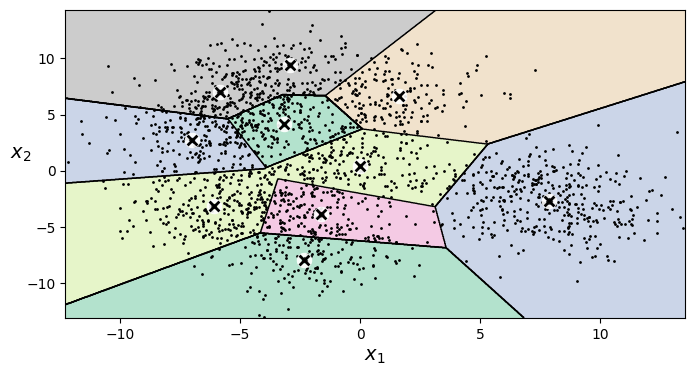

In [39]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [40]:
kmeans.transform(X_new)

array([[10.23124655,  3.81356267,  9.15964987,  7.0332189 ,  6.07494553,
         7.9848607 ,  1.56036619,  4.90743899,  7.9172243 ,  7.68468164],
       [11.29460015,  6.51827609,  6.75235272, 10.02180131,  7.45603473,
        10.45112732,  3.36682031,  4.84051587,  9.43922814, 10.15339956],
       [10.98729508,  1.14948004, 12.26903387,  4.00405552,  6.99502584,
         6.90266122,  3.9565848 ,  5.87050176,  6.36663685,  4.90166352],
       [10.48831427,  1.64619283, 12.04643716,  4.00176808,  6.5056844 ,
         6.45897324,  3.652983  ,  6.19266146,  6.86658278,  5.31711606]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.



In [41]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=10, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=10, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=10, n_init=1, random_state=5)


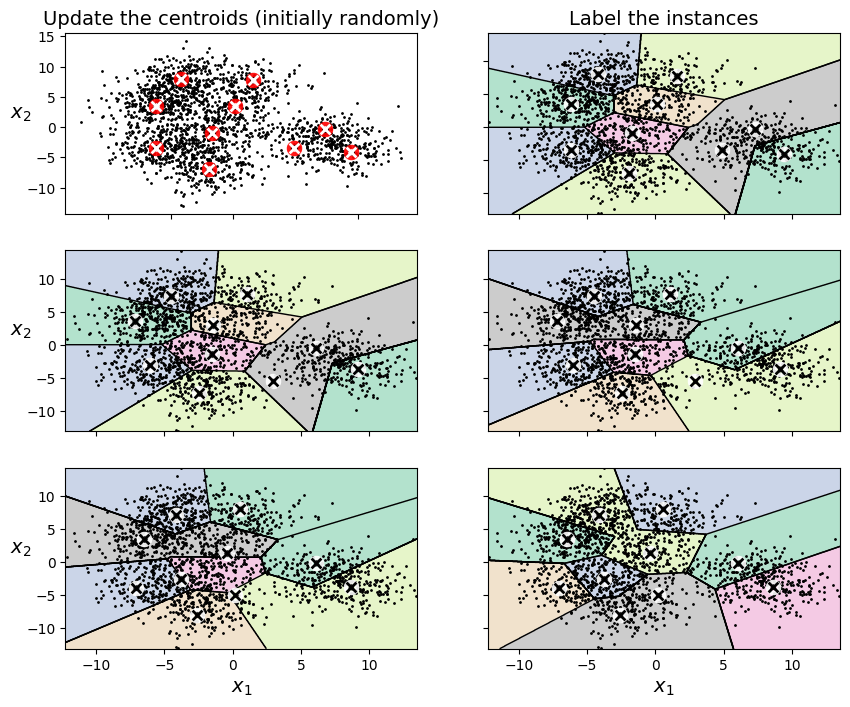

In [42]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [43]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

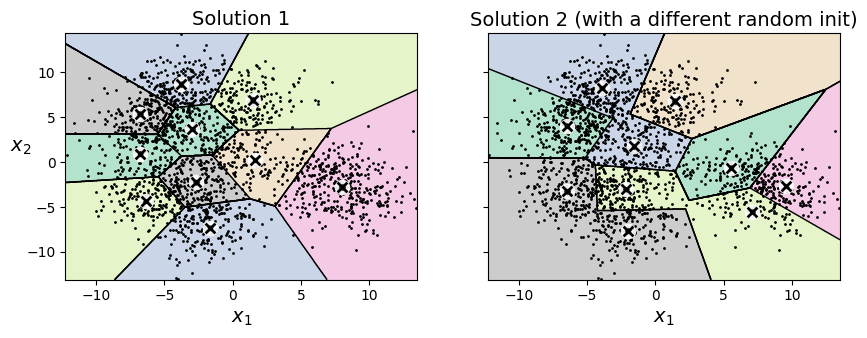

In [44]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.

In [45]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=10, n_init=10,
       random_state=11)


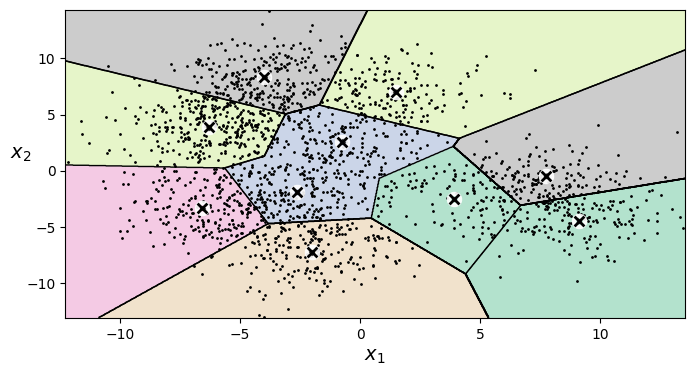

In [46]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto, que optimiza el cálculo de distancias) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria. A continuación veremos cómo funciona este último usando el dataset MNIST, empleando el objeto [MiniBatchKMeans]

In [47]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [48]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [49]:
best_kmeans.score(X)

-20230.918185951978

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.



### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.



In [50]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.36362926867524314)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

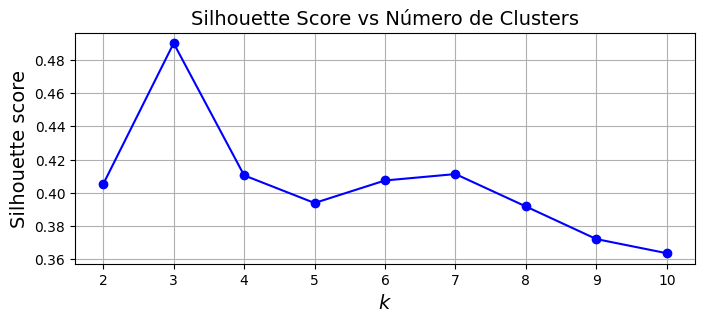

In [51]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

### ELBOW METHOD

Calcula la inercia para distintos valores de k

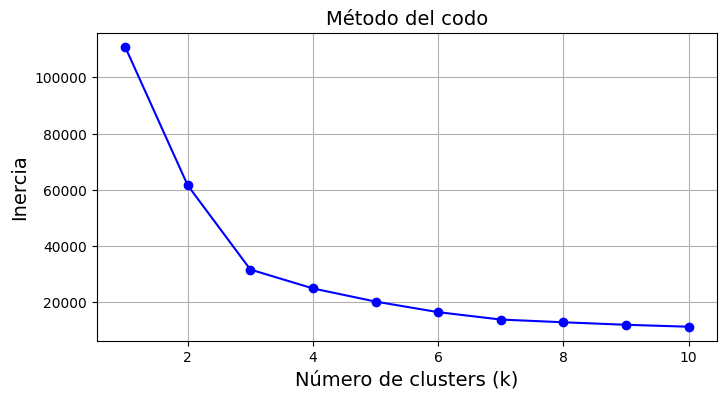

In [52]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

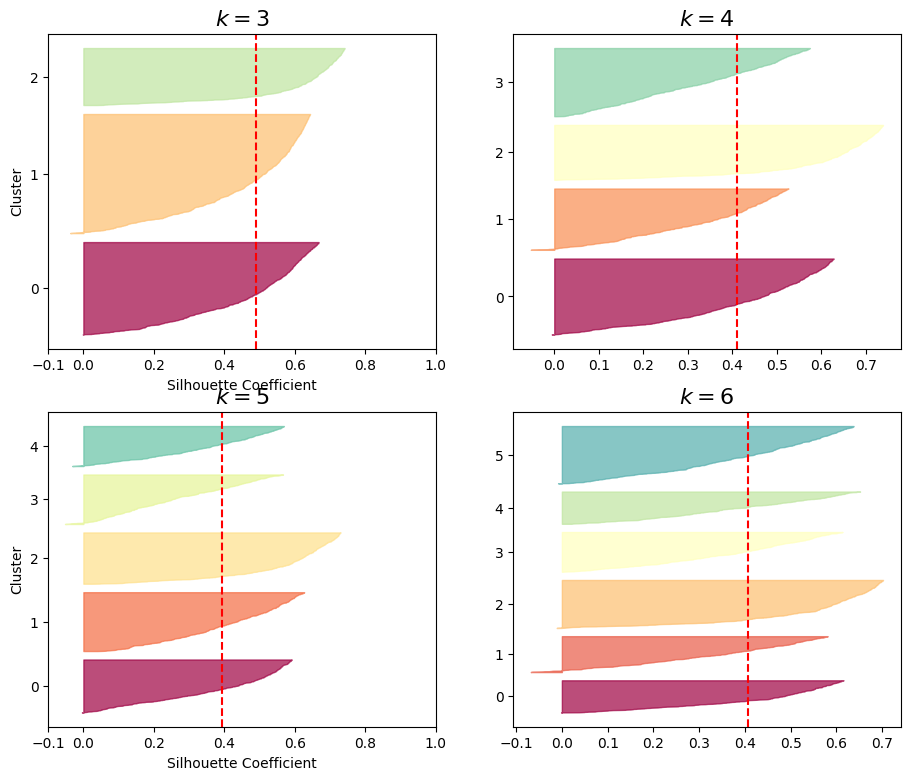

In [53]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

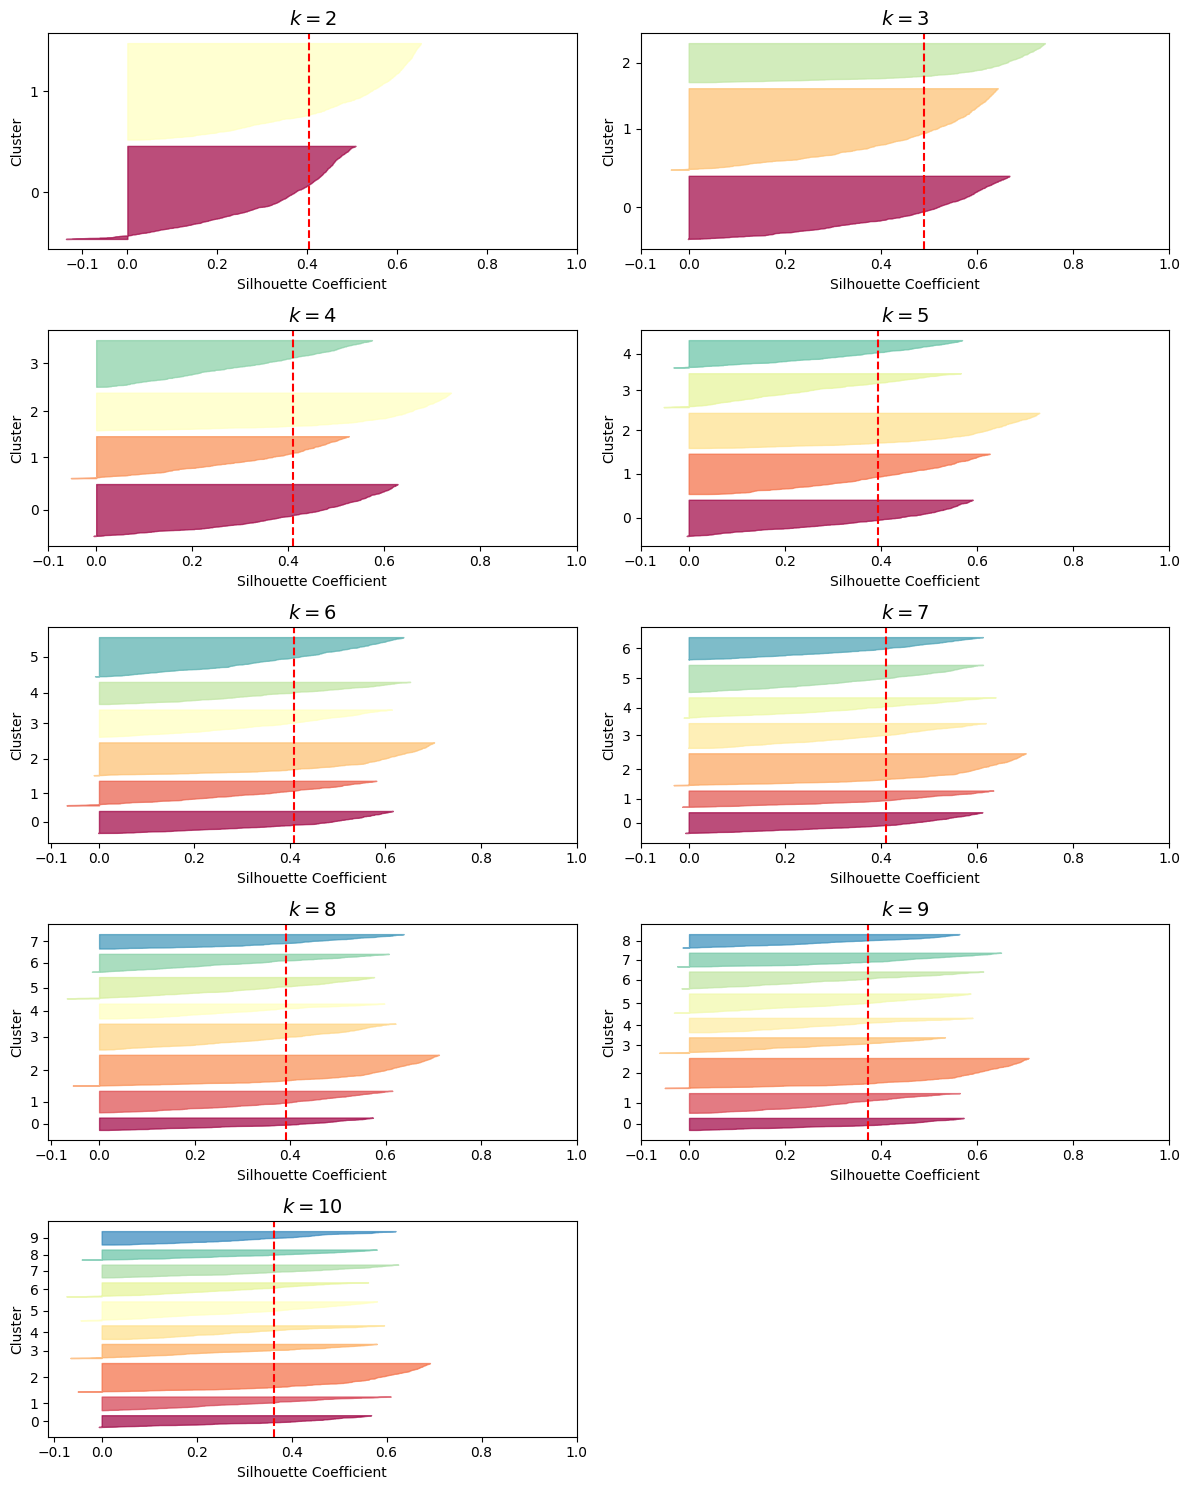

In [54]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


## 2.-  K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset bloodMNIST y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.



In [55]:
import os
import requests

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
classes = [
    "cat", "dog", "tree", "house", "car",
    "apple", "chair", "cup", "bicycle", "clock"
]

os.makedirs("data", exist_ok=True)

for cls in classes:
    url = base_url + cls + ".npy"
    path = f"data/{cls}.npy"

    if not os.path.exists(path):
        print(f"Descargando {cls}...")
        r = requests.get(url)
        with open(path, "wb") as f:
            f.write(r.content)

In [56]:
import numpy as np

X = []
y = []

samples_per_class = 8000

for i, cls in enumerate(classes):
    data = np.load(f"data/{cls}.npy")

    data = data[:samples_per_class]  # recorte

    X.append(data)
    y.append(np.full(samples_per_class, i))

X = np.concatenate(X)
y = np.concatenate(y)

(80000, 784)


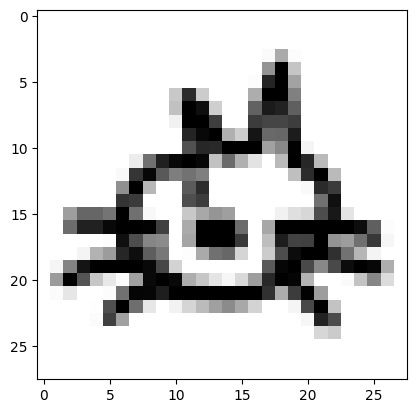

In [57]:
print(X.shape)  # (n_samples, 784)

import matplotlib.pyplot as plt

img = X[0].reshape(28, 28)
plt.imshow(img, cmap="binary")
plt.show()

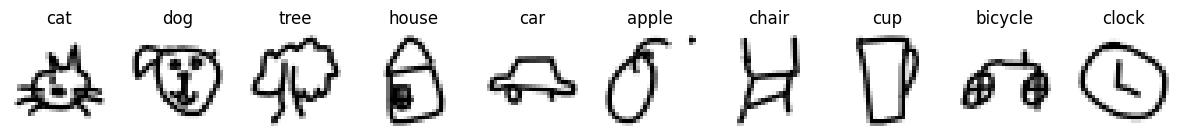

In [58]:
plt.figure(figsize=(15, 3))
for i, cls in enumerate(classes):
    plt.subplot(1, 10, i + 1)
    # Tomamos la primera imagen de cada bloque de 8000
    img = X[i * samples_per_class].reshape(28, 28)
    plt.imshow(img, cmap="binary")
    plt.title(cls)
    plt.axis('off')
plt.show()

In [59]:
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 50 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

In [61]:
from sklearn.cluster import KMeans

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
# X_digits_dist

In [62]:
print(X_digits_dist.shape)
print(X_digits_dist)

(64000, 50)
[[2341.53261716 1949.07107536 2402.28016458 ... 2527.35464382
  2238.63095043 2435.02887262]
 [2211.88888811 2634.97279849 2395.30030375 ... 2509.67528964
  2324.9685009  2566.30613382]
 [2550.54544023 2808.14820725 1976.1356717  ... 2491.99283015
  2412.89083337 2564.08814494]
 ...
 [2375.85882945 2327.37920359 2445.89051835 ... 2792.81454753
  2434.72993911 2638.41377491]
 [2354.24600947 2094.61257616 2530.99937885 ... 2780.9357758
  2375.23157294 2679.75152434]
 [2516.54564059 2247.52577384 2535.14024624 ... 2963.58824216
  2475.9488022  2850.31511723]]


In [63]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]


In [64]:
print(X_representative_digits.shape)
print(X_representative_digits)

(50, 784)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


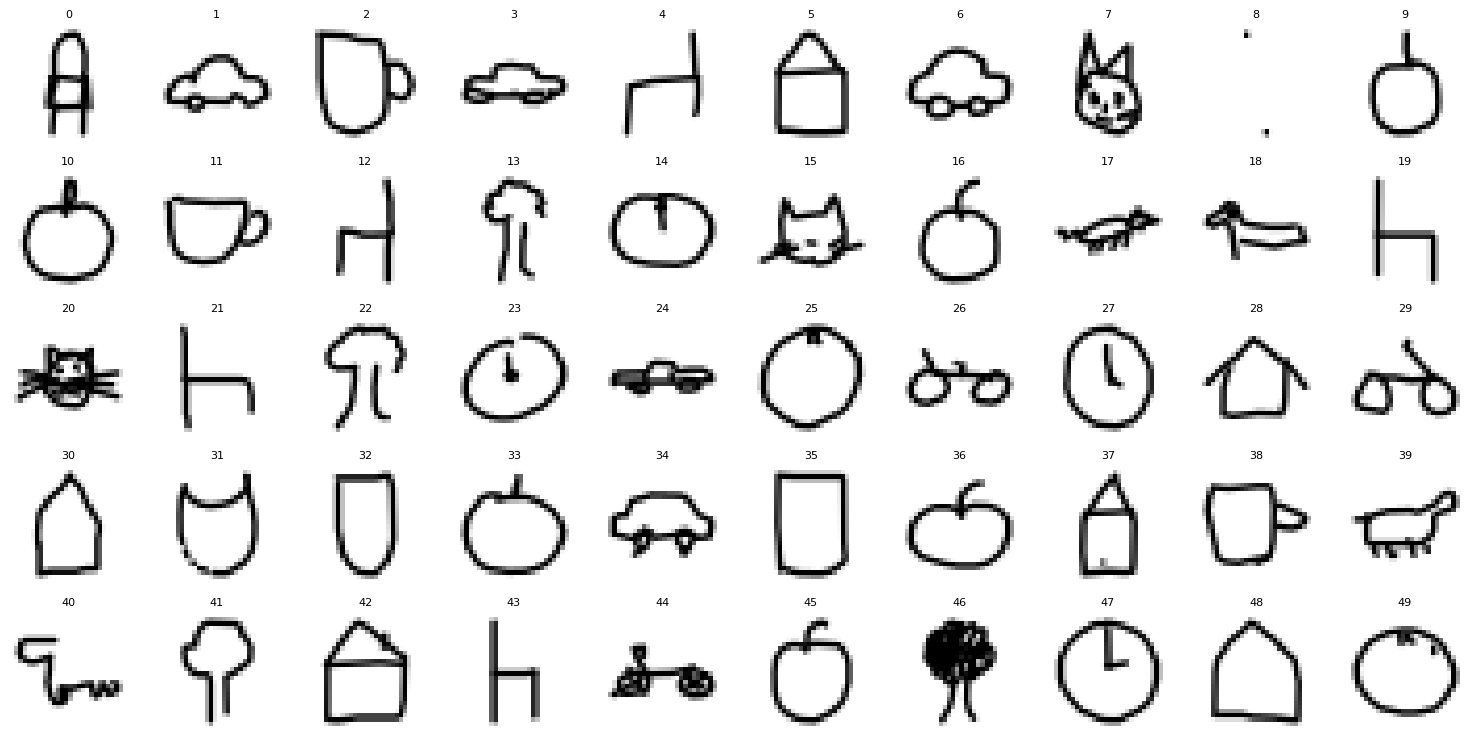

In [65]:
import matplotlib.pyplot as plt
import math

# Número de imágenes representativas
n_digits = len(X_representative_digits)

# Definir tamaño de la cuadrícula (lo más cuadrada posible)
n_cols = 10
n_rows = math.ceil(n_digits / n_cols)

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))

for i, img in enumerate(X_representative_digits):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(img.reshape(28, 28), cmap="binary")
    plt.title(f"{i}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

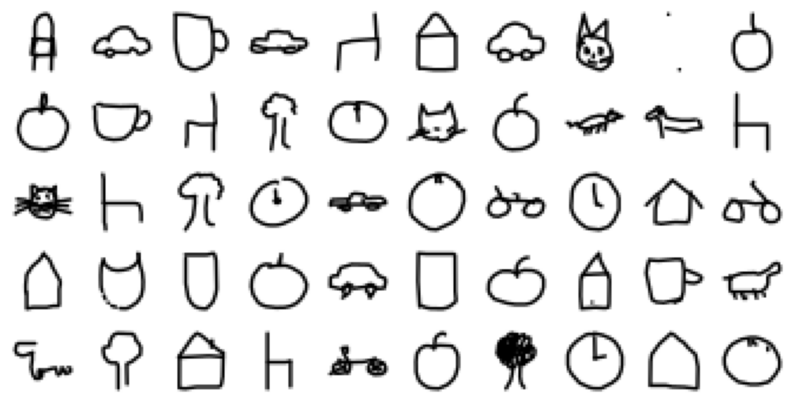

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(5, 10, index+1)
  plt.imshow(X_representative_digit.reshape(28,28), cmap="binary")
  plt.axis('off')
plt.show()


El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [67]:
y_representative_digits = y_train[idxs]

Y entrenaremosusando estas imágenes representativas.

In [68]:
from sklearn.linear_model import LogisticRegression


log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_val, y_val)

CPU times: user 170 ms, sys: 672 µs, total: 170 ms
Wall time: 93.3 ms


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.5649375

Como puedes observar hemos obtenido una precisión de casi el $56%$ habiendo anotado simplemente 50 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 50 imágenes aleatorias nos daría peores resultados.

In [69]:
idxs = np.random.choice(len(X_train), 50, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs], y_train[idxs])
log_reg.score(X_val, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 250 ms, sys: 914 µs, total: 251 ms
Wall time: 130 ms


0.446

A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos.
Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante.

In [70]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [71]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_val, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 3.3 s, sys: 2.34 ms, total: 3.3 s
Wall time: 1.71 s


0.6020625

A veces, al intentar mejorar el modelo añadiendo más datos etiquetados automáticamente, el resultado puede ser peor. Esto ocurre porque no todas las imágenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que estén más cerca de los representantes de cada grupo, o bien recurrir a técnicas de aprendizaje activo para seleccionar mejor qué ejemplos anotar.

## 3.-  Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [72]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.9998006 , 0.99980323, 0.999811  , 0.99982148, 0.99982601,
       0.99982913, 0.99983865, 0.99984093, 0.99984378, 0.99986068])

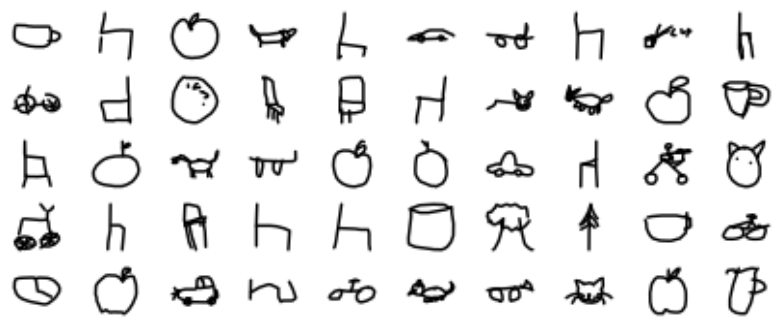

In [73]:
import math
rows = math.ceil(k / 10)

X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(rows, 10, index + 1)
    plt.imshow(img.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [74]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([7, 6, 5, 1, 6, 4, 8, 6, 7, 6, 8, 6, 9, 6, 6, 6, 0, 0, 5, 7, 6, 5,
       1, 6, 5, 5, 4, 6, 8, 0, 8, 6, 6, 6, 6, 7, 2, 4, 7, 8, 9, 5, 4, 6,
       8, 1, 8, 0, 5, 7])

In [75]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [76]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_val, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 3.05 s, sys: 1.81 ms, total: 3.06 s
Wall time: 1.57 s


0.6141875